In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from simulation.simulation import (
    simulate_outer_market_paths,
    compute_fixing_window_size,
    simulate_nested_cva,
    simulate_nested_cva_swaptions_gpu,
)
from simulation.stats import cva_stats_swaps, cva_stats_swaptions
from products.irs.gpu import calibrate_swap_rate_at_par
from products.swaption.cpu import price_bermudan_swaption

In this notebook we consider a bank engaged in bilateral trading with a single client. Let $R$ denote the recovery rate of the client upon its default at time $\tau$, assumed to settle instantaneously ($\delta = 0$). The portfolio is of maturity $T$ and uncollateralized, and we assume no contractual cash flows between the bank and the client at $\tau$. We denote by $MtM$ the mark-to-market process of the portfolio. The credit valuation adjustment at time $t$, what the bank expects to lose due to the counterparty's default, is then given by
$$
\mathrm{CVA}_t
=
\mathbb{E}_t
\left[
\mathbf{1}_{\{t<\tau\leq T\}}\,
\beta_t^{-1}\beta_{\tau}\,
(1-R)\,
(MtM_{\tau})^{+}
\right],
$$ where the stochastic discount factor is defined by 
$\beta_t=\exp\!\left(-\int_0^t r_s\,ds\right)$.
We discretize $[0,T]$ over a grid $0=t_0<t_1<\dots<t_n=T$ with terminal condition $\mathrm{CVA}_{t_n}=0$. 
The default event $\{t_l<\tau\leq t_{l+1}\}$ triggers a loss settled at $t_{l+1}$ with exposure at default $(1-R)(MtM_{t_{l+1}})^+$. 
This implies that for $i=n-1,\dots,0$,
$$
\mathrm{CVA}_{t_i}
=
\mathbb{E}_{t_i}
\left[
\sum_{l=i}^{n-1}
\beta_{t_i}^{-1}\,\beta_{t_{l+1}}\,
(1-R)\,
(MtM_{t_{l+1}})^+\,
\mathbf{1}_{\{t_l<\tau\leq t_{l+1}\}}
\right].
$$
We also introduce (introduced in the course and following Albanese, Crépey, Hoskinson and Saadeddine [[1]](#achs)), the intensity-based formulation of the CVA:
$$
\mathrm{CVA}_t
=
\mathbb{1}_{\{t<\tau\}}\,\mathbb{E}_t\!\left[
\int_t^T
\beta_t^{-1}\,\beta_s\,(1-R)\,(MtM_s)^+\,
\gamma_s\,\exp\!\left(-\int_t^s \gamma_u\,du\right)
ds
\right].
$$
The explicit scheme gives
$$
\int_{t_i}^{T}
\beta_s\,(MtM_s)^+\,
\gamma_s\,\exp\!\left(-\int_{t_i}^s \gamma_u\,du\right)ds
\;\approx\;
\sum_{l=i}^{n-1}
\beta_{t_l}\,(MtM_{t_l})^+
\int_{t_l}^{t_{l+1}}
\gamma_s\,\exp\!\left(-\int_{t_i}^s \gamma_u\,du\right)ds,
$$
where the client default-density factor integrates as:
$$
\int_{t_l}^{t_{l+1}}
\gamma_s\,\exp\!\left(-\int_{t_i}^s \gamma_u\,du\right)ds
=
\exp\!\Big(\!-\!\int_{t_i}^{t_l}\gamma_u\,du\Big)
-
\exp\!\Big(\!-\!\int_{t_i}^{t_{l+1}}\gamma_u\,du\Big).
$$
This gives for $i = n-1, \dots, 0$,
$$
\mathrm{CVA}_{t_i}
=
\mathbb{E}_{t_i}\!\left[
\sum_{l=i}^{n-1}
\beta_{t_i}^{-1}\,\beta_{t_l}\,(1-R)\,(MtM_{t_l})^+
\left(
\exp\!\Big(\!-\!\int_{t_i}^{t_l}\gamma_u\,du\Big)
-
\exp\!\Big(\!-\!\int_{t_i}^{t_{l+1}}\gamma_u\,du\Big)
\right)
\mathbb{1}_{\{t_i<\tau\}}
\right].
$$

The CVA is an anticipation of future default losses conditional on the information $\mathcal{F}_{t_i}$ available at $t_i$. This information is carried by the pair $(Z_{t_i}, X_{t_i})$, where $Z_{t_i}$ gathers the market risk factors (e.g. a Vasicek short rate, a CIR default intensity, an asset price $S_t$..) and $X_{t_i} = \mathbf{1}_{\{t_i \leq \tau \}}$ is the client's default indicator.

In the following $R = 0$.

In this notebook, we first estimate these conditional expectations by nested Monte Carlo method. An outer i.i.d. sample $\{(Z_{t_i}^{(k)}, \tau^{(k)})\}_{1 \leq k \leq N}$ and, for each $k$, $M$ inner paths drawn conditionally on $(Z_{t_i}, \mathbf{1}_{\{\tau > t_i\}}) = (Z_{t_i}^{(k)}, \mathbf{1}_{\{\tau^{(k)} > t_i\}})$.

For a given outer $k$:

Indicator estimator ($\tau^{(k,m)}$ re-simulated per inner path):
$$
\widehat{\mathrm{CVA}}_{t_i}^{(k)}
= \frac{1}{M} \sum_{m=1}^{M} \sum_{l=i}^{n-1}
\beta_{t_i}^{-1} \beta_{t_{l+1}}^{(k,m)} \big(MtM_{t_{l+1}}^{(k,m)}\big)^{+}
\mathbf{1}_{\{t_l < \tau^{(k,m)} \leq t_{l+1}\}}.
$$

Intensity-based estimator:
$$
\widehat{\mathrm{CVA}}_{t_i}^{(k)}
= \frac{1}{M} \sum_{m=1}^{M} \sum_{l=i}^{n-1}
\beta_{t_i}^{-1} \beta_{t_l}^{(k,m)} \big(MtM_{t_l}^{(k,m)}\big)^{+}
\Big(e^{-\int_{t_i}^{t_l} \gamma_u^{(k,m)} du} - e^{-\int_{t_i}^{t_{l+1}} \gamma_u^{(k,m)} du}\Big)
\mathbf{1}_{\{t_i < \tau^{(k)}\}}.
$$

As mentioned in [[2]](#acs) and in the course, the intensity-based formulation gives a lower-variance estimator of the CVA. 

### Case study 1 : IRS 

In [2]:
# time discretization grid
dT = 0.1
num_substeps = 5
dt = dT / num_substeps      
T_horizon = 10.0
num_steps_total = round(T_horizon / dT)   

In [3]:
# Risk factors parameters 
# Vasicek short rate (a, b, sigma)
# CIR default intensity (k, theta, xi)
a, b, sigma = 0.3, 0.03, 0.01
k, theta, xi = 0.5, 0.015, 0.01
rho = 0
diff_params = (a, b, sigma, k, theta, xi)
r_0, gamma_0 = 0.01, 0.015

In [4]:
num_outer_paths = 2**15

In [5]:
nested_cva_dates = [2.5, 7.5]                                   
t_i_idx_table = [round(t / dT) for t in nested_cva_dates]       

In [6]:
# swaps ptf
np.random.seed(0)

num_irs = 100
reset_freq = 0.5

# bank ptf direction bias
prop_pay_fixed = 0.75  # heavy asset
notional = 10000. * (np.random.choice((-1, 1), num_irs, p=(1 - prop_pay_fixed, prop_pay_fixed)) * np.random.choice(range(1, 11), num_irs))

at_par = False   # if true the mtm=0 at t_0 else fixed swap_rate 

irs = []
for i in range(num_irs):
    trade = {
        'first_reset': reset_freq,
        'reset_freq':  reset_freq,
        'num_resets':  int(np.random.randint(6, 21)),
        'notional':    float(notional[i]),
        'swap_rate':   float(np.random.uniform(0.005, 0.05))  # (course case study), random ITM/OTM
    }
    if at_par:
        trade['swap_rate'] = float(
            calibrate_swap_rate_at_par(trade, r_0, a, b, sigma))
    irs.append(trade)

print(f"{num_irs} swaps | p_pay_fixed={prop_pay_fixed} | at_par={at_par} | "
      f"max maturity={max(s['num_resets'] for s in irs)*reset_freq:.1f}y")

100 swaps | p_pay_fixed=0.75 | at_par=False | max maturity=10.0y


In [7]:
fixing_window_size = compute_fixing_window_size(irs, dt, dT)
print("fixing_window_size =", fixing_window_size)

fixing_window_size = 5


In [8]:
# outer paths simulation + risk factors diffusion 
rng = np.random.default_rng(42)
X, default_step, _, _ = simulate_outer_market_paths(
        num_outer_paths= num_outer_paths,
        num_steps_total=num_steps_total,
        num_substeps=num_substeps,
        dt=dt,
        fixing_window_size=fixing_window_size,
        r_0=r_0, gamma_0=gamma_0,
        diff_params=diff_params,
        rho=rho, rng=rng)               

As discussed in the course (NMC design parameterization) and [[3]](#acd) suggest $M_{inner} \sim \sqrt{M_{outer}}$ as the optimal balance for the NMC. 
For example, for $M_{outer} = 2^{15}$ this gives $M_{inner} \simeq 180$, around which its grid below is built.
We also check that the intensity-based estimator to display tighter CIs than the indicator-based one. The intensity-based table is therefore expected to display tighter confidence intervals at every $M_{inner}$.

In [9]:
# this cell studies the convergence of the CVA 
# CVA vs M_inner for both estimators (indicator/intensity) at selected t_i (nested cva dates)
# Identify M_inner from which CVA stabilizes 

dict_nmc = {
    2**12: [16, 32, 64, 128, 256, 512],  # of sqrt = 64
    2**15: [16, 32, 64, 128, 256, 512],  # of sqrt = 181
}

for M_outer, M_inner_grid in dict_nmc.items():
    # outer paths simualtion 
    rng = np.random.default_rng(42) # fixed outer paths + fixed random seed across M_inner values
    X, default_step, _, _ = simulate_outer_market_paths(
        num_outer_paths= M_outer,
        num_steps_total=num_steps_total,
        num_substeps=num_substeps,
        dt=dt,
        fixing_window_size=fixing_window_size,
        r_0=r_0, gamma_0=gamma_0,
        diff_params=diff_params,
        rho=rho, rng=rng)
    print("X shape:", X.shape, "| defaults:", (default_step != -1).sum())

    for t_i in nested_cva_dates:
        t_i_idx = round(t_i / dT)
        for indicator, label in [(False, "intensity"), (True, "indicator")]:
            rows = []
            for n_inner in M_inner_grid:
                cva, ic, rel, sec = cva_stats_swaps(
                t_i_idx, n_inner, indicator,
                X, default_step, irs,
                diff_params, rho, dt, num_substeps, num_steps_total,
                M_outer, fixing_window_size, dT, seed=42,)
                rows.append([n_inner, f"{cva:.2f}", f"±{ic:.2f}",
                         f"{rel:.2f}%", f"{sec:.2f}"])
            df = pd.DataFrame(rows, columns=["M_inner", "CVA value",
                                         "CI 95%", "Rel err.", "exec time (sec)"])
            print(f"\n CVA ({label}) at t_i={t_i}, M_cva={M_outer}")
            print(df.to_string(index=False))

X shape: (105, 2, 4096) | defaults: 570


/opt/python/lib/python3.13/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 32 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))



 CVA (intensity) at t_i=2.5, M_cva=4096
 M_inner CVA value CI 95% Rel err. exec time (sec)
      16    886.52 ±21.94    2.48%            3.09
      32    890.78 ±21.65    2.43%            0.74
      64    890.78 ±21.48    2.41%            1.47
     128    892.73 ±21.40    2.40%            2.94
     256    892.56 ±21.31    2.39%            5.87
     512    892.10 ±21.26    2.38%           11.74

 CVA (indicator) at t_i=2.5, M_cva=4096
 M_inner CVA value CI 95% Rel err. exec time (sec)
      16    941.08 ±54.82    5.83%            0.37
      32    911.16 ±40.32    4.43%            0.73
      64    891.91 ±31.10    3.49%            1.46
     128    869.92 ±25.78    2.96%            2.91
     256    878.05 ±23.40    2.67%            5.82
     512    877.25 ±21.95    2.50%           11.63

 CVA (intensity) at t_i=7.5, M_cva=4096
 M_inner CVA value CI 95% Rel err. exec time (sec)
      16     50.92  ±2.11    4.14%            0.04
      32     50.88  ±2.11    4.14%            0.08
      64  

Both estimators converge to consistent values ≈400 (intensity) vs ≈370 (indicator) at $t_i = 2.5$, and ≈127.4 at $t_i = 7.5$. 
The intensity estimator is more stable across the whole grid.
The indicator estimator needs more inner paths to reach comparable CI widths to the intensity based-one, confirming the variance-reduction property of the intensity formualtion.

We retain $M_{inner} = 128$ for upcoming single NMC CVA estimates.

### Case study 2 : Bermudan swaption

In the previous case of a book of swaps, $\text{MtM}$ was analytic. We now add a Bermudan swaption where the holder may enter the underlying swap at any date of a discrete exercise grid $\Re = \{s_0, \dots, s_{N_b}\} \subset \{t_0, \dots, t_n\}$ with maturity $T$. As noted in [[3]](#acd) and in the course, a non-analytic $MtM$ would in principle require an extra layer of inner simulations.

Let $\varphi$ denote the exercise payoff. The pre-default pricing function satisfies at each exercise date $s_k$ is given by 

$$P(s_k, Z_{s_k}) = \operatorname*{ess\,sup}_{\theta \in \mathcal{T}^k} \mathbb{E}\!\left[\tfrac{\beta_\theta}{\beta_{s_k}} \varphi(Z_\theta) \,\big|\, Z_{s_k}\right],$$

where $\mathcal{T}^k$ is the set of stopping times valued in $\{s_k, \dots, s_{N_b}\}$. The optimal stopping time is obtained by the standard backward recursion $\tau^*_{N_b} = T$ and, for $k$ decreasing from $N_b - 1$ to $0$,

$$\tau^*_k = s_k \mathbf{1}_{A_k} + \tau^*_{k+1} \mathbf{1}_{A_k^c}, \qquad A_k = \big\{ \beta_{s_k} \varphi(Z_{s_k}) > \mathbb{E}[\beta_{s_{k+1}} P(s_{k+1}, Z_{s_{k+1}}) \mid Z_{s_k}] \big\},$$

so that $\text{MtM}_{s_k} = P(s_k, Z_{s_k}) = \mathbb{E}[\beta_{s_k}^{-1} \beta_{\tau^*_k} \varphi(Z_{\tau^*_k}) \mid Z_{s_k}]$. The conditional expectations defining $A_k$ are approximated by Longstaff-Schwartz regression on a polynomial basis of $Z_{s_k}$ [[3]](#acd) [[4]](#course).

In the nested monte carlo context, this Longstaff-Schwartz procedure is re-run inside each outer simulation at every outer node $(t_i, Z_{t_i}^{(k)})$ where $\text{MtM}$ is needed, $M$ inner trajectories of the risk factor $Z$ are simulated from that point and a local Longstaff-Schwartz gives the inner estimator $\widehat{\text{MtM}}^{(k,m)}$ which is then plugged into the CVA we've seen above.

In this context $\varphi(Z_{s_k}) = \big(V^{\text{swap}}(s_k, Z_{s_k})\big)^+$ where $V^{\text{swap}}(s_k, Z_{s_k})$ is the value at $s_k$ of the underlying swap.

In this section we determine teh CVA at $t = 0$ (no inner conditioning). 
The NMC reduces to two layers :
- Outer : $M_{cva}$ paths of $(r, \gamma, \tau)$ simulated once from $0$ to $T$
- Inner LS : $M_{LS}$ paths used locally for the Longstaff-Schwartz pricing at every outer node where the MtM is needed

Plugging this into the indicator-based estimator for example for outer path $k$:

$$
\widehat{\mathrm{CVA}}_0^{(k)} = \sum_{l=0}^{n-1} \beta_{t_{l+1}}^{(k)} \Big(\widehat{\mathrm{MtM}}_{t_{l+1}}^{(k)}\Big)^+ \mathbf{1}_{\{t_l < \tau^{(k)} \leq t_{l+1}\}}
$$

The GPU kernel for thsi nmc simualtion is built around the natural mapping 1 thread = 1 outer path. Each thread runs sequentially the full inner LS for each swaption of the book. This is also presented in [[3]](#acd) (Appendix). Other implementation choices were interesting to add. The polynomial regression of the continuation value is restricted to in-the-money paths only to improve accuracy [[5]](#giles). Moreover, the regression step at each LS iteration requires solving many small symmetric positive-definite systems in parallel (one per outer node per exercise date per swaption) as standard regression operators (such as numpy's lstsq) are not available on GPU. The regression step is therefore implemented via a Cholesky factorization following a dedicated GPU strategy developed in [[3]](#acd) [[6]](#atg).

In [ ]:
# swaptions book
np.random.seed(1)

num_swaptions = 100
reset_freq = 0.5

# bank ptf direction bias/ heavy asset
prop_payer = 0.75
swap_types = np.random.choice((-1, 1), num_swaptions, p=(1 - prop_payer, prop_payer))
notional = 10000. * np.random.choice(range(1, 11), num_swaptions)

swaptions = []
for i in range(num_swaptions):
    trade = {
        'first_reset': float(np.random.choice([1.0, 1.5, 2.0])),  # non-callable period/lock-out drawn in {1y, 1.5y, 2y}
        'reset_freq':  reset_freq,
        'num_resets':  int(np.random.randint(10, 17)),
        'notional':    float(notional[i]),
        'swap_rate':   float(np.random.uniform(0.005, 0.05)),
        'swap_type':   int(swap_types[i]),
    }
    swaptions.append(trade)

max_maturity = max(s['first_reset'] + (s['num_resets'] - 1) * reset_freq for s in swaptions)
print(f"{num_swaptions} swaptions | p_payer={prop_payer} | "
      f"lock-out in [1.0, 2.0]y | max maturity={max_maturity:.1f}y")

100 swaptions | p_payer=0.75 | lock-out in [1.0, 2.0]y | max maturity=9.5y


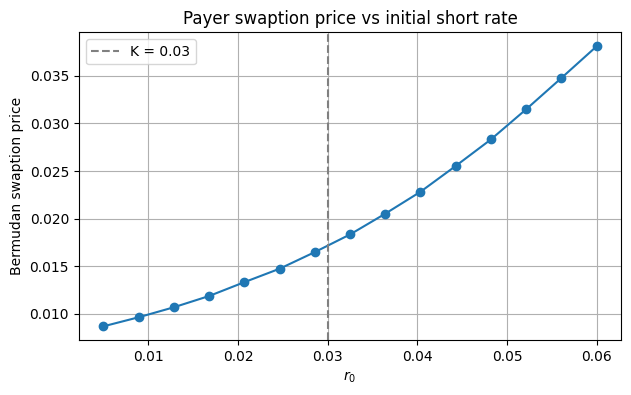

In [ ]:
# sanity check
# payer swaption price as a function of the initial short rate
#swaption_test = {
#    'first_reset': 2.0, 'reset_freq': 0.5, 'num_resets': 11,
#    'swap_rate': 0.03, 'swap_type': 1, 'notional': 1.0,
#}

#r_0_grid = np.linspace(0.005, 0.06, 15)  # ITM/ATM/OTM regimes
#prices = []
#for r0 in r_0_grid:
#    rng = np.random.default_rng(42)
#    p = price_bermudan_swaption(
#       t=0.0, r_0=r0, swaption=swaption_test,
#        M=5000, dt=0.02, a=0.3, b=0.03, sigma=0.01, N_b=3, rng=rng,
#   )
#   prices.append(p)

#plt.figure(figsize=(7, 4))
#plt.plot(r_0_grid, prices, 'o-')
#plt.axvline(swaption_test['swap_rate'], ls='--', c='gray',
#            label=f"K = {swaption_test['swap_rate']}")
#plt.xlabel("$r_0$")
#plt.ylabel("Bermudan swaption price")
#plt.title("Payer swaption price vs initial short rate")
#plt.legend()
#plt.grid(True)
#plt.show()

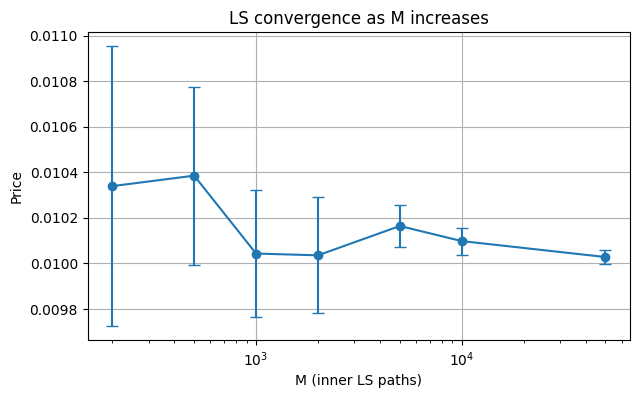

In [11]:
# testing LS convergence
# for each M run 10 independent estimates + varying the seed
#M_grid = [200, 500, 1000, 2000, 5000, 10000, 50000]
#n_repeats = 10

#mean_prices = []
#ic_95 = []
#for M in M_grid:
#    samples = [price_bermudan_swaption(
#        t=0.0, r_0=0.01, swaption=swaption_test,
#        M=M, dt=0.02, a=0.3, b=0.03, sigma=0.01, N_b=3,
#        rng=np.random.default_rng(seed),
#    ) for seed in range(n_repeats)]
#    mean_prices.append(np.mean(samples))
#    ic_95.append(1.96 * np.std(samples, ddof=1) / np.sqrt(n_repeats))

#plt.figure(figsize=(7, 4))
#plt.errorbar(M_grid, mean_prices, yerr=ic_95, fmt='o-', capsize=4)
#plt.xscale('log')
#plt.xlabel("M (inner LS paths)")
#plt.ylabel("Price")
#plt.title("LS convergence as M increases")
#plt.grid(True)
#plt.show()

price stabilizes around as M grows and the 95% CI shrinks.

In [ ]:
# This cell studies the convergence of the for the swaptions book
# CVA vs M_LS (number of paths in the inner Longstaff-Schwartz regression)

num_outer_paths_test = 1024
num_inner_ls_grid = [8, 16, 32, 64]

rng = np.random.default_rng(42)
X_swpt, default_step_swpt, rate_integral_path_swpt, gamma_integral_path_swpt = simulate_outer_market_paths(
    num_outer_paths=num_outer_paths_test,
    num_steps_total=num_steps_total,
    num_substeps=num_substeps,
    dt=dt,
    fixing_window_size=fixing_window_size,
    r_0=r_0, gamma_0=gamma_0,
    diff_params=diff_params,
    rho=rho, rng=rng,
)
print(f"outer paths simulated | defaults: {(default_step_swpt != -1).sum()}/{num_outer_paths_test}")

for indicator, label in [(False, "intensity"), (True, "indicator")]:
    rows = []
    for n_inner in num_inner_ls_grid:
        cva, ic, rel, sec = cva_stats_swaptions(
            n_inner, indicator, swaptions,
            X_swpt, default_step_swpt,
            rate_integral_path_swpt, gamma_integral_path_swpt,
            diff_params, rho, dt, dT, num_substeps, num_steps_total,
            num_outer_paths_test, fixing_window_size, seed=42,
        )
        rows.append([n_inner, f"{cva:.2f}", f"±{ic:.2f}",
                     f"{rel:.2f}%", f"{sec:.2f}"])
    df = pd.DataFrame(rows, columns=["M_LS (inner LS paths)", "CVA value",
                                     "CI 95%", "rel err.", "exec time (sec)"])
    print(f"\n CVA swaptions ({label}), M_cva={num_outer_paths_test}")
    print(df.to_string(index=False))

outer paths simulated | defaults: 139/1024


/opt/python/lib/python3.13/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 8 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))



 CVA swaptions (intensity), M_cva=1024
 M_LS (inner LS paths) CVA value  CI 95% rel err. exec time (sec)
                     8   5161.80 ±185.95    3.60%           22.59
                    16   5193.58 ±185.36    3.57%           19.40
                    32   5153.98 ±184.81    3.59%           38.83
                    64   5112.01 ±184.72    3.61%           78.04

 CVA swaptions (indicator), M_cva=1024
 M_LS (inner LS paths) CVA value   CI 95% rel err. exec time (sec)
                     8   4627.96 ±1142.77   24.69%            0.22
                    16   4620.64 ±1140.43   24.68%            0.47
                    32   4604.85 ±1135.28   24.65%            0.88
                    64   4568.54 ±1130.48   24.74%            1.87


The intensity estimator is stable across the grid with a nearly flat CI of order 185. The indicator estimator suffers from a very wider CI (≈24% rel. error) and this is due to the low number of defaults in the outer sample (139/1024). I kept $M_{cva}$ low here, as I tried to increase it, the GPU memory crashed. As far as I understand The inner LS kernel allocates/stores large local arrays for the short-rate + integrated-rate snapshots + Cholesky workspace and that saturates quickly. I should do more work on shared-memory usage or use a better GPU.

## References

<a id="achs"></a>
**[1]** C. Albanese, S. Crépey, R. Hoskinson, B. Saadeddine.
*XVA Analysis From the Balance Sheet.* Quantitative Finance, 21(1), 99–123, 2021.

<a id="acs"></a>
**[2]** L. A. Abbas-Turki, S. Crépey, B. Saadeddine.
*Pathwise CVA Regressions With Oversimulated Defaults.* Mathematical Finance, 2022.

<a id="acd"></a>
**[3]** L. A. Abbas-Turki, S. Crépey, B. Diallo.
*XVA Principles, Nested Monte Carlo Strategies, and GPU Optimizations.* International Journal of Theoretical and Applied Finance, 21(6), 1850030, 2018.

<a id="course"></a>
**[4]** J.F. Chassagneux.  
*Numerical Methods in Financial Engineering.* Course notes, 2026.

<a id="giles"></a>
**[5]** M. Giles.
*Advanced Monte Carlo Methods: American Options.* Lecture notes, Oxford University Mathematical Institute.

<a id="atg"></a>
**[6]** L. A. Abbas-Turki, S. Graillat.
*Resolution of a large number of small random symmetric linear systems in single precision arithmetic on GPUs.* Journal of Supercomputing, 73(4), 1360–1386, 2017.

<a id="ls"></a>
**[7]** F. A. Longstaff, E. S. Schwartz.
*Valuing American Options by Simulation: A Simple Least-Squares Approach.* Anderson Graduate School of Management, Finance, UCLA, 2001.

<a id="aaad"></a>
**[8]** B. Saadeddine. *NeuralXVA: simulation and neural-net learning of path-wise XVAs.* GitHub repository, 2020.

<a id="gpw"></a>
**[9]** M. Germain, H. Pham, X. Warin.
 *Approximation error analysis of some deep backward schemes for nonlinear PDEs.* SIAM Journal on Scientific Computing, 43(5), 2021.

<a id="acss"></a>
**[10]** L. Abbas-Turki, S. Crépey, B. Saadeddine, W. Sabbagh.
 *Pathwise XVAs: The Direct Scheme.* Preprint, 31 October 2022.

<a id="fg"></a>
**[11]** R. Ferguson, A. Green. 
*Deeply Learning Derivatives.* Preprint, version 2.1, 14 October 2018. arXiv:1809.02233.